In [15]:
import subprocess
subprocess.run(["pip", "install", "ultralytics", "-q"], check=True)
print("ultralytics installed")

ultralytics installed


In [16]:
import os, json, pickle, shutil, random
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
 
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


In [17]:
DATA_ROOT     = Path("/kaggle/input/datasets/sahilakolte/vr-project-1/dataset/processed")
TRAIN_IMG_DIR = DATA_ROOT / "train"      / "images"
TRAIN_ANN_DIR = DATA_ROOT / "train"      / "annos"
VAL_IMG_DIR   = DATA_ROOT / "validation" / "images"
VAL_ANN_DIR   = DATA_ROOT / "validation" / "annos"
YOLO_DIR      = Path("/kaggle/working/yolo_dataset")
OUT_DIR       = Path("/kaggle/working/yolo_transfer")
OUT_DIR.mkdir(parents=True, exist_ok=True)


Load metadata

In [18]:
with open(DATA_ROOT / "top5.pkl", "rb") as f:
    top5_data = pickle.load(f)
with open(DATA_ROOT / "label_map.pkl", "rb") as f:
    label_map = pickle.load(f)
with open(DATA_ROOT / "train_labels.pkl", "rb") as f:
    train_labels = pickle.load(f)
with open(DATA_ROOT / "val_labels.pkl", "rb") as f:
    val_labels = pickle.load(f)
 
ALL_CATEGORIES = {
    1:"short_sleeve_top",    2:"long_sleeve_top",
    3:"short_sleeve_outwear",4:"long_sleeve_outwear",
    5:"vest",                6:"sling",
    7:"shorts",              8:"trousers",
    9:"skirt",               10:"short_sleeve_dress",
    11:"long_sleeve_dress",  12:"vest_dress",
    13:"sling_dress"
}
CLASS_NAMES = [ALL_CATEGORIES[cat_id] for cat_id in top5_data]
NUM_CLASSES  = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"label_map: {label_map}")

Classes (5): ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']
label_map: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


Stratified sampling

In [19]:
def stratified_sample_yolo(labels_dict, img_dir, fraction=0.3,
                            num_classes=5, min_per_class=500, seed=42):
    random.seed(seed)
    class_buckets = {i: [] for i in range(num_classes)}
    for filename, label_arr in labels_dict.items():
        if not (img_dir / filename).exists():
            continue
        for i, v in enumerate(label_arr):
            if v == 1.0:
                class_buckets[i].append(filename)
 
    print("Class distribution BEFORE sampling:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  [{i}] {name:<28s}: {len(class_buckets[i])}")
 
    sampled_keys = set()
    for i in range(num_classes):
        bucket = class_buckets[i]
        n      = max(min_per_class, int(len(bucket) * fraction))
        chosen = random.sample(bucket, min(n, len(bucket)))
        sampled_keys.update(chosen)
 
    sampled_dict = {k: labels_dict[k] for k in sampled_keys if k in labels_dict}
    print(f"\nAfter sampling: {len(sampled_dict)}/{len(labels_dict)} "
          f"({len(sampled_dict)/len(labels_dict)*100:.1f}%)")
    print("Class distribution AFTER sampling:")
    for i, name in enumerate(CLASS_NAMES):
        count = sum(1 for arr in sampled_dict.values() if arr[i] == 1.0)
        print(f"  [{i}] {name:<28s}: {count}")
    return sampled_dict
 
train_labels_sampled = stratified_sample_yolo(
    train_labels, TRAIN_IMG_DIR,
    fraction=0.15, num_classes=NUM_CLASSES, min_per_class=500
)
 
# Val/test split
val_keys  = list(val_labels.keys())
random.shuffle(val_keys)
mid       = len(val_keys) // 2
test_keys = val_keys[mid:]
val_keys  = val_keys[:mid]
test_labels = {k: val_labels[k] for k in test_keys}
val_labels  = {k: val_labels[k] for k in val_keys}
print(f"\nTrain:{len(train_labels_sampled)}  Val:{len(val_labels)}  Test:{len(test_labels)}")

Class distribution BEFORE sampling:
  [0] short_sleeve_top            : 70586
  [1] trousers                    : 54969
  [2] shorts                      : 36332
  [3] long_sleeve_top             : 35751
  [4] skirt                       : 30625

After sampling: 32244/144174 (22.4%)
Class distribution AFTER sampling:
  [0] short_sleeve_top            : 17629
  [1] trousers                    : 13015
  [2] shorts                      : 8737
  [3] long_sleeve_top             : 9029
  [4] skirt                       : 7552

Train:32244  Val:11870  Test:11871


Build YOLO dataset

In [20]:
def polygon_to_yolo(polygons, img_w, img_h):
    for poly in polygons:
        if len(poly) >= 6:
            pts = []
            for i in range(0, len(poly) - 1, 2):
                pts.append(max(0.0, min(1.0, poly[i]   / img_w)))
                pts.append(max(0.0, min(1.0, poly[i+1] / img_h)))
            if len(pts) >= 6:
                return pts
    return None
 
def bbox_fallback(bbox, img_w, img_h):
    x1, y1, x2, y2 = bbox
    c = [x1/img_w, y1/img_h, x2/img_w, y1/img_h,
          x2/img_w, y2/img_h, x1/img_w, y2/img_h]
    return [max(0.0, min(1.0, v)) for v in c]
 
def write_yolo_split(labels_dict, img_dir, ann_dir, split_name, force=False):
    img_out = YOLO_DIR / "images" / split_name
    lbl_out = YOLO_DIR / "labels" / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
 
    existing = list(lbl_out.glob("*.txt"))
    if not force and len(existing) > 50:
        print(f"  {split_name}: {len(existing)} labels already exist — skipping")
        return
 
    written = 0
    for filename in tqdm(labels_dict.keys(), desc=f"Build {split_name}"):
        img_path = img_dir / filename
        if not img_path.exists(): continue
        try:
            with Image.open(img_path) as im:
                img_w, img_h = im.size
        except Exception:
            continue
        stem     = Path(filename).stem
        ann_path = ann_dir / (stem + ".json")
        lines    = []
        if ann_path.exists():
            try:
                with open(ann_path) as f:
                    ann = json.load(f)
                for key in ann:
                    if not key.startswith("item"): continue
                    item   = ann[key]
                    cat_id = item.get("category_id")
                    if cat_id not in label_map: continue
                    label = label_map[cat_id]
                    pts   = (polygon_to_yolo(item.get("segmentation", []), img_w, img_h)
                             or bbox_fallback(item.get("bounding_box", [0,0,img_w,img_h]), img_w, img_h))
                    lines.append(f"{label} " + " ".join(f"{v:.6f}" for v in pts))
            except Exception:
                pass
        if not lines: continue
        dst = img_out / filename
        if not dst.exists():
            try: os.symlink(img_path.resolve(), dst)
            except Exception: shutil.copy2(img_path, dst)
        with open(lbl_out / (stem + ".txt"), "w") as f:
            f.write("\n".join(lines))
        written += 1
    print(f"  {split_name}: {written} images written")
 
print("Building YOLO dataset...")
write_yolo_split(train_labels_sampled, TRAIN_IMG_DIR, TRAIN_ANN_DIR, "train")
write_yolo_split(val_labels,           VAL_IMG_DIR,   VAL_ANN_DIR,   "val")
write_yolo_split(test_labels,          VAL_IMG_DIR,   VAL_ANN_DIR,   "test")
 
yaml_path = YOLO_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    f.write(f"path: {YOLO_DIR}\n"
            f"train: images/train\n"
            f"val: images/val\n"
            f"test: images/test\n"
            f"nc: {NUM_CLASSES}\n"
            f"names: {CLASS_NAMES}\n")
print(f"data.yaml ready")

Building YOLO dataset...
  train: 32244 labels already exist — skipping
  val: 11870 labels already exist — skipping
  test: 11871 labels already exist — skipping
data.yaml ready


Train YOLO TRANSFER LEARNING

In [21]:
print("\n" + "="*55)
print("YOLO TRANSFER LEARNING (COCO → Apparel)")
print("="*55)
 
model = YOLO("yolov8n-seg.pt")   # COCO pretrained — downloaded automatically
 
results = model.train(
    data         = str(yaml_path),
    epochs       = 20,             
    imgsz        = 640,
    batch        = 8,             
    device       = device,
    project      = str(OUT_DIR),
    name         = "train",
    optimizer    = "AdamW",
    lr0          = 1e-4,           # lower LR — backbone already trained
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 5e-4,
    warmup_epochs= 3,
    cos_lr       = True,
    freeze       = 10,             # freeze first 10 backbone layers
    patience     = 10,             # early stopping
    cls          = 0.5,
    box          = 7.5,
    dfl          = 1.5,
    flipud       = 0.1,
    fliplr       = 0.5,
    mosaic       = 0.8,
    mixup        = 0.05,
    degrees      = 5,
    translate    = 0.1,
    scale        = 0.5,
    plots        = True,
    save         = True,
    verbose      = True,
    seed         = SEED,
    workers      = 2,
)
print("Training complete!")


YOLO TRANSFER LEARNING (COCO → Apparel)
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=A

Validate

In [22]:
best_weights = OUT_DIR / "train" / "weights" / "best.pt"
model_best   = YOLO(str(best_weights))
 
val_results = model_best.val(
    data=str(yaml_path), split="val",
    imgsz=640, batch=8, device=device, plots=True, verbose=True,
)
print(f"\nmAP@0.5      (seg): {val_results.seg.map50:.4f}")
print(f"mAP@0.5:0.95 (seg): {val_results.seg.map:.4f}")
print(f"mAP@0.5      (box): {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95 (box): {val_results.box.map:.4f}")

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,039 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 30.9±15.7 MB/s, size: 43.8 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 11870 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11870/11870 4.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1484/1484 13.3it/s 1:52<0.1s
                   all      11870      19391       0.79      0.802      0.842      0.691      0.786      0.797      0.833      0.629
      short_sleeve_top       6269       6346      0.832      0.891      0.929       0.82      0.833      0.891      0.928      0.744
              trousers       4750       4795      0.822      0.854      0.857      0.672       0.81       0.84      0.836      0.591
                shorts

mIoU and Dice

In [23]:
print("\nComputing mIoU and Dice...")
try:
    import cv2
    IMG_SIZE  = 640
    inter_sum = np.zeros(NUM_CLASSES)
    union_sum = np.zeros(NUM_CLASSES)
    pred_sum  = np.zeros(NUM_CLASSES)
    gt_sum    = np.zeros(NUM_CLASSES)
    val_imgs  = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:300]
    if not val_imgs:
        val_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.png"))[:300]
 
    for img_path in tqdm(val_imgs, desc="mIoU/Dice"):
        stem     = img_path.stem
        lbl_path = YOLO_DIR / "labels" / "val" / (stem + ".txt")
        if not lbl_path.exists(): continue
        gt_masks = {c: np.zeros((IMG_SIZE, IMG_SIZE), np.uint8) for c in range(NUM_CLASSES)}
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7: continue
                cls = int(parts[0])
                pts = np.array(parts[1:], float).reshape(-1, 2)
                pts[:, 0] *= IMG_SIZE; pts[:, 1] *= IMG_SIZE
                cv2.fillPoly(gt_masks[cls], [pts.astype(np.int32)], 1)
        preds = model_best.predict(str(img_path), imgsz=IMG_SIZE, verbose=False, device=device)
        pred_masks = {c: np.zeros((IMG_SIZE, IMG_SIZE), np.uint8) for c in range(NUM_CLASSES)}
        if preds and preds[0].masks is not None:
            for mask, cls in zip(preds[0].masks.data.cpu().numpy(),
                                  preds[0].boxes.cls.cpu().numpy().astype(int)):
                if cls < NUM_CLASSES:
                    m = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
                    pred_masks[cls] = np.clip(pred_masks[cls] + (m > 0.5), 0, 1).astype(np.uint8)
        for c in range(NUM_CLASSES):
            inter_sum[c] += (pred_masks[c] & gt_masks[c]).sum()
            union_sum[c] += (pred_masks[c] | gt_masks[c]).sum()
            pred_sum[c]  += pred_masks[c].sum()
            gt_sum[c]    += gt_masks[c].sum()
 
    iou_arr  = inter_sum / (union_sum + 1e-6)
    dice_arr = (2 * inter_sum) / (pred_sum + gt_sum + 1e-6)
    print(f"\nPer-class — YOLO (Transfer):")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  [{i}] {name:<28s}: IoU={iou_arr[i]:.4f}  Dice={dice_arr[i]:.4f}")
    print(f"  Mean IoU : {iou_arr.mean():.4f}")
    print(f"  Mean Dice: {dice_arr.mean():.4f}")
except ImportError:
    print("cv2 not found — skipping mIoU/Dice")
    iou_arr = dice_arr = np.zeros(NUM_CLASSES)


Computing mIoU and Dice...


mIoU/Dice: 100%|██████████| 300/300 [00:07<00:00, 41.86it/s]


Per-class — YOLO (Transfer):
  [0] short_sleeve_top            : IoU=0.5500  Dice=0.7097
  [1] trousers                    : IoU=0.5306  Dice=0.6933
  [2] shorts                      : IoU=0.1973  Dice=0.3295
  [3] long_sleeve_top             : IoU=0.3806  Dice=0.5513
  [4] skirt                       : IoU=0.5190  Dice=0.6833
  Mean IoU : 0.4355
  Mean Dice: 0.5934


Detection ROC / AUC / F1


Computing detection ROC/AUC/F1...


Det metrics: 100%|██████████| 300/300 [00:04<00:00, 68.96it/s]


Detection F1 — Macro:0.7074  Micro:0.7450


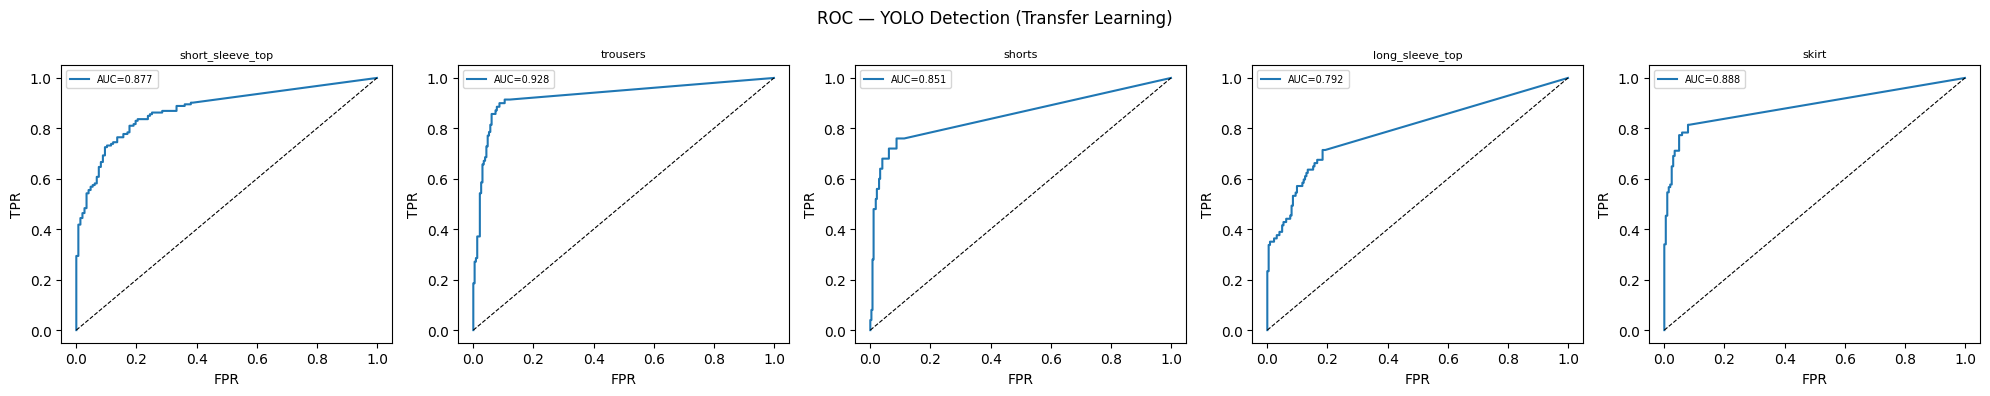

In [24]:
print("\nComputing detection ROC/AUC/F1...")
val_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:300]
if not val_imgs:
    val_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.png"))[:300]
 
y_true, y_scores = [], []
for img_path in tqdm(val_imgs, desc="Det metrics"):
    stem     = img_path.stem
    lbl_path = YOLO_DIR / "labels" / "val" / (stem + ".txt")
    gt_vec   = np.zeros(NUM_CLASSES)
    if lbl_path.exists():
        for line in open(lbl_path):
            cls = int(line.split()[0])
            if cls < NUM_CLASSES: gt_vec[cls] = 1
    try:
        preds     = model_best.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=device)
        score_vec = np.zeros(NUM_CLASSES)
        if preds and preds[0].boxes is not None:
            for cls, conf in zip(preds[0].boxes.cls.cpu().numpy().astype(int),
                                  preds[0].boxes.conf.cpu().numpy()):
                if cls < NUM_CLASSES:
                    score_vec[cls] = max(score_vec[cls], float(conf))
    except Exception:
        score_vec = np.zeros(NUM_CLASSES)
    y_true.append(gt_vec); y_scores.append(score_vec)
 
y_true   = np.array(y_true)
y_scores = np.array(y_scores)
y_pred   = (y_scores >= 0.25).astype(int)
det_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
det_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
print(f"Detection F1 — Macro:{det_macro:.4f}  Micro:{det_micro:.4f}")
 
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4*NUM_CLASSES, 4))
auc_scores = []
for i, name in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        auc = roc_auc_score(y_true[:, i], y_scores[:, i])
        auc_scores.append(auc); axes[i].plot(fpr, tpr, label=f"AUC={auc:.3f}")
    except Exception:
        auc_scores.append(0.0); axes[i].text(0.5, 0.5, "N/A", ha="center")
    axes[i].plot([0,1],[0,1],"k--",lw=0.8)
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("FPR"); axes[i].set_ylabel("TPR")
    axes[i].legend(fontsize=7)
plt.suptitle("ROC — YOLO Detection (Transfer Learning)")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_curves.png", dpi=100)
plt.show()


Qualitative predictions

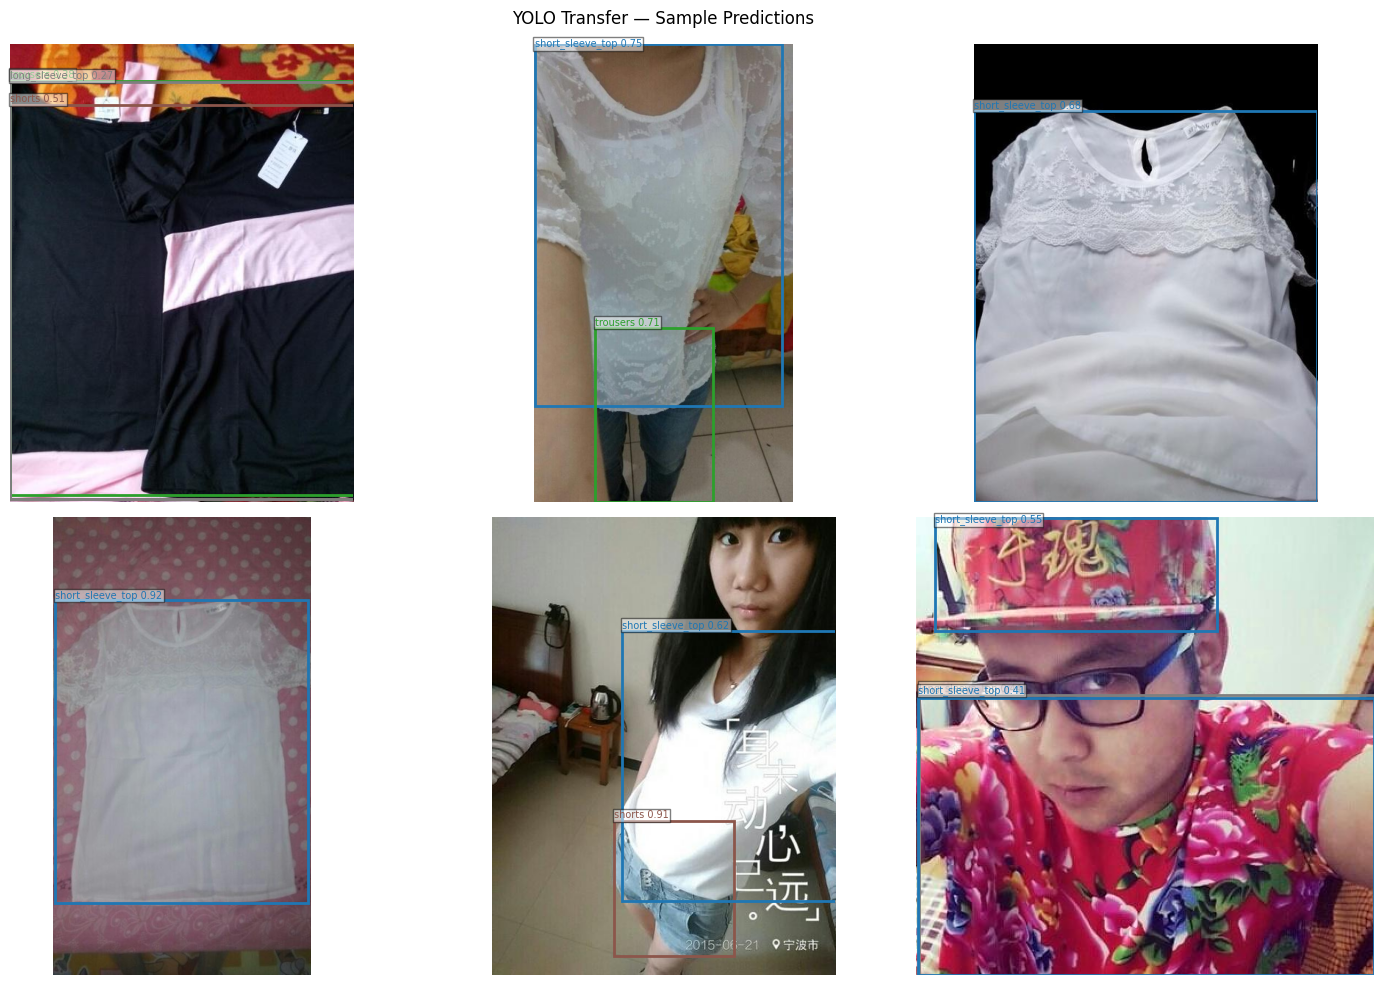

In [25]:
sample_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:6]
if not sample_imgs:
    sample_imgs = sorted((YOLO_DIR / "images" / "val").glob("*.png"))[:6]
 
if sample_imgs:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    for ax, img_path in zip(axes, sample_imgs):
        try:
            preds = model_best.predict(str(img_path), imgsz=640,
                                        conf=0.25, verbose=False, device=device)
            img = np.array(Image.open(img_path).convert("RGB"))
            ax.imshow(img)
            if preds and preds[0].boxes is not None:
                for box, cls, conf in zip(
                    preds[0].boxes.xyxy.cpu().numpy(),
                    preds[0].boxes.cls.cpu().numpy().astype(int),
                    preds[0].boxes.conf.cpu().numpy(),
                ):
                    x1,y1,x2,y2 = box
                    c    = colors[cls % len(colors)]
                    rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                              linewidth=2, edgecolor=c, facecolor="none")
                    ax.add_patch(rect)
                    lbl = CLASS_NAMES[cls] if cls < NUM_CLASSES else str(cls)
                    ax.text(x1, max(y1-4,4), f"{lbl} {conf:.2f}", color=c, fontsize=7,
                            bbox=dict(facecolor="white", alpha=0.5, pad=1))
            ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:50], ha="center", fontsize=7)
    for ax in axes[len(sample_imgs):]:
        ax.axis("off")
    plt.suptitle("YOLO Transfer — Sample Predictions")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "qualitative_predictions.png", dpi=100, bbox_inches="tight")
    plt.show()

Save results

In [26]:
results_summary = {
    "model": "YOLOv8n-seg", "training": "transfer_learning", "pretrained_on": "COCO",
    "map50_seg": float(val_results.seg.map50), "map_seg":  float(val_results.seg.map),
    "map50_box": float(val_results.box.map50), "map_box":  float(val_results.box.map),
    "mean_mIoU": float(iou_arr.mean()),        "mean_dice": float(dice_arr.mean()),
    "iou_per_class":  iou_arr.tolist(),        "dice_per_class": dice_arr.tolist(),
    "det_f1_macro":   det_macro,               "det_f1_micro":   det_micro,
    "auc_per_class":  auc_scores,              "class_names":    CLASS_NAMES,
}
with open(OUT_DIR / "results.pkl", "wb") as f:
    pickle.dump(results_summary, f)
 
print(f"\n{'='*55}")
print("YOLO TRANSFER LEARNING — FINAL SUMMARY")
print(f"{'='*55}")
print(f"mAP@0.5      (seg): {val_results.seg.map50:.4f}")
print(f"mAP@0.5:0.95 (seg): {val_results.seg.map:.4f}")
print(f"Mean mIoU         : {iou_arr.mean():.4f}")
print(f"Mean Dice         : {dice_arr.mean():.4f}")
print(f"Det F1 (macro)    : {det_macro:.4f}")
print(f"Mean AUC          : {np.mean(auc_scores):.4f}")
print(f"Best weights      : {best_weights}")
print(f"All outputs       : {OUT_DIR}")


YOLO TRANSFER LEARNING — FINAL SUMMARY
mAP@0.5      (seg): 0.8329
mAP@0.5:0.95 (seg): 0.6291
Mean mIoU         : 0.4355
Mean Dice         : 0.5934
Det F1 (macro)    : 0.7074
Mean AUC          : 0.8672
Best weights      : /kaggle/working/yolo_transfer/train/weights/best.pt
All outputs       : /kaggle/working/yolo_transfer



0: 640x480 1 short_sleeve_top, 8.1ms
Speed: 2.2ms preprocess, 8.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)


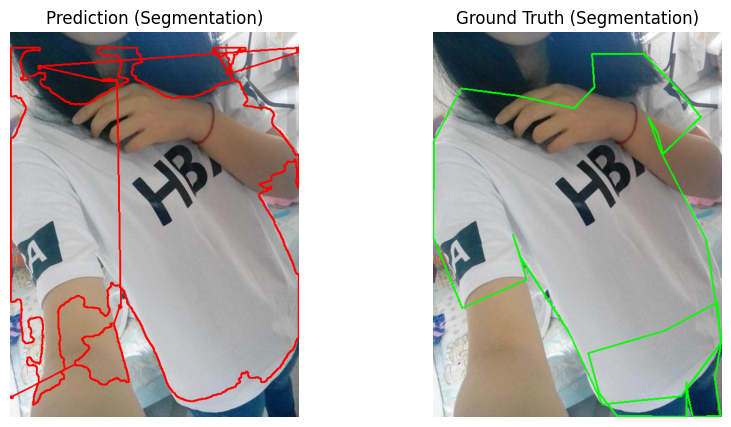


0: 640x448 2 short_sleeve_tops, 1 trousers, 8.7ms
Speed: 2.6ms preprocess, 8.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 448)


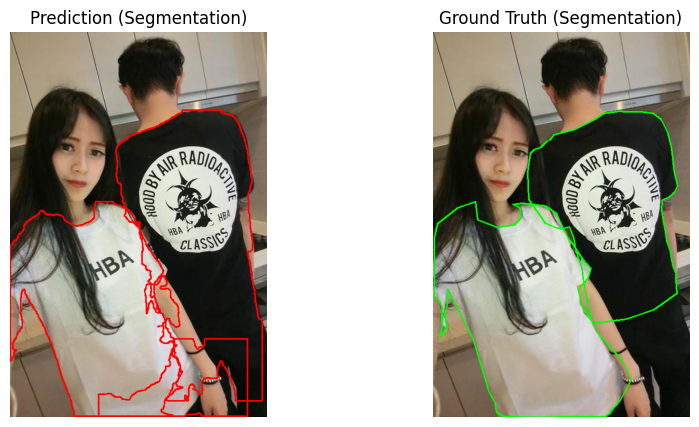

In [27]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt


IMAGE_DIR = "/kaggle/input/datasets/sahilakolte/vr-project-1/hidden_dataset/hidden_dataset/images"
ANNO_DIR  = "/kaggle/input/datasets/sahilakolte/vr-project-1/hidden_dataset/hidden_dataset/annos"

NUM_IMAGES = 10
image_files = sorted(os.listdir(IMAGE_DIR))[:NUM_IMAGES]

for img_name in image_files:

    img_path = os.path.join(IMAGE_DIR, img_name)
    json_path = os.path.join(ANNO_DIR, img_name.replace(".jpg", ".json"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # -------------------------
    # MODEL PREDICTION (SEGMENTATION)
    # -------------------------
    results = model(img)   # YOLOv8 segmentation model

    pred_img = img.copy()

    for r in results:
        if r.masks is not None:
            for mask in r.masks.xy:     # polygon points
                pts = np.array(mask, dtype=np.int32)
                cv2.polylines(pred_img, [pts], True, (255,0,0), 2)   # blue = prediction

    # -------------------------
    # GROUND TRUTH (from JSON)
    # -------------------------
    gt_img = img.copy()

    with open(json_path) as f:
        data = json.load(f)

    for key in ["item1", "item2"]:   # your json contains 2 objects
        if key in data:
            seg = data[key]["segmentation"][0]

            pts = np.array(seg).reshape(-1,2).astype(np.int32)
            cv2.polylines(gt_img, [pts], True, (0,255,0), 2)  # green = ground truth

    # -------------------------
    # SHOW RESULT
    # -------------------------
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Prediction (Segmentation)")
    plt.imshow(pred_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ground Truth (Segmentation)")
    plt.imshow(gt_img)
    plt.axis("off")

    plt.show()